In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import mne
import sys
sys.path.append(os.path.abspath(".."))
from eegkit.models import SubjectFilterDTO, EpochParamsDTO
from eegkit.controller import EEGController
from eegkit.models.subject_model import EEGSubjectModel


In [5]:
# Path to your HBN EEG dataset root
data_dir = f'/mount/NAS-public-dataset/HBN-EEG'

# Init subject model and controller
subject_model = EEGSubjectModel(data_dir)
controller = EEGController(subject_model)

# Pick a subject with SuS task
task_dto = SubjectFilterDTO(task="surroundSupp", ccd_accuracy_range=(81.9444,None), ccd_response_time_range=(1.6324,None),subject_limit=5)

In [6]:
# Define epoching/filter params
params = EpochParamsDTO(
    l_freq=3.0, h_freq=55.0,   # bandpass
    tmin=-2.0, tmax=2.4         # epoch window in sec
)

epochs, labels = controller.get_epochs(task_dto, params)
print("Epochs shape:", epochs.get_data().shape)
print("Available labels:", list(epochs.event_id.keys()))

Finding participants_combind.tsv on /mount/NAS-public-dataset/HBN-EEG/participants_combind.tsv
Found
['sub-NDARAN385MDH', 'sub-NDARAP359UM6', 'sub-NDARBD879MBX', 'sub-NDARBK082PDD', 'sub-NDARCZ947WU5']
5 subjects found


Building epochs:   0%|          | 0/10 [00:00<?, ?it/s]

concatenating 10 epochs


/mount/NAS-workspace-portal/eeg2025-Vistec/eegkit/models/cohort_model.py:92: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  self.epochs = concatenate_epochs(epochs_list)


Epochs shape: (640, 128, 2201)
Available labels: ['bg1_fg0.0_stim2', 'bg1_fg0.3_stim3', 'bg1_fg0.6_stim1', 'bg1_fg1.0_stim2', 'bg1_fg0.0_stim3', 'bg1_fg0.3_stim2', 'bg1_fg1.0_stim3', 'bg0_fg0.0_stim3', 'bg0_fg0.3_stim1', 'bg0_fg0.6_stim2', 'bg0_fg1.0_stim3', 'bg1_fg1.0_stim1', 'bg1_fg0.6_stim3', 'bg1_fg0.0_stim1', 'bg1_fg0.6_stim2', 'bg0_fg0.0_stim2', 'bg0_fg0.6_stim3', 'bg0_fg1.0_stim2', 'bg1_fg0.3_stim1', 'bg0_fg1.0_stim1', 'bg0_fg0.3_stim2', 'bg0_fg0.0_stim1', 'bg0_fg0.3_stim3']


In [9]:
tmin = -2.0
tmax = 2.4
fmin = 1.0
fmax = 55.0
sfreq = epochs.info["sfreq"]

spectrum = epochs.compute_psd(
    "welch",
    n_fft=int(sfreq * (tmax - tmin)),
    n_overlap=0,
    n_per_seg=None,
    tmin=tmin,
    tmax=tmax,
    fmin=fmin,
    fmax=fmax,
    window="boxcar",
    verbose=False,
)
psds, freqs = spectrum.get_data(return_freqs=True)

In [10]:

# Define epoching/filter params
params = EpochParamsDTO(
    l_freq=3.0, h_freq=55.0,   # bandpass
    tmin=-2.0, tmax=2.4         # epoch window in sec
)

epochs, labels = controller.get_epochs(task_dto, params)
print("Epochs shape:", epochs.get_data().shape)
print("Available labels:", list(epochs.event_id.keys()))

Epochs shape: (640, 128, 2201)
Available labels: ['bg1_fg0.0_stim2', 'bg1_fg0.3_stim3', 'bg1_fg0.6_stim1', 'bg1_fg1.0_stim2', 'bg1_fg0.0_stim3', 'bg1_fg0.3_stim2', 'bg1_fg1.0_stim3', 'bg0_fg0.0_stim3', 'bg0_fg0.3_stim1', 'bg0_fg0.6_stim2', 'bg0_fg1.0_stim3', 'bg1_fg1.0_stim1', 'bg1_fg0.6_stim3', 'bg1_fg0.0_stim1', 'bg1_fg0.6_stim2', 'bg0_fg0.0_stim2', 'bg0_fg0.6_stim3', 'bg0_fg1.0_stim2', 'bg1_fg0.3_stim1', 'bg0_fg1.0_stim1', 'bg0_fg0.3_stim2', 'bg0_fg0.0_stim1', 'bg0_fg0.3_stim3']


In [11]:
def snr_spectrum(psd, noise_n_neighbor_freqs=1, noise_skip_neighbor_freqs=1):
    """Compute SNR spectrum from PSD spectrum using convolution.

    Parameters
    ----------
    psd : ndarray, shape ([n_trials, n_channels,] n_frequency_bins)
        Data object containing PSD values. Works with arrays as produced by
        MNE's PSD functions or channel/trial subsets.
    noise_n_neighbor_freqs : int
        Number of neighboring frequencies used to compute noise level.
        increment by one to add one frequency bin ON BOTH SIDES
    noise_skip_neighbor_freqs : int
        set this >=1 if you want to exclude the immediately neighboring
        frequency bins in noise level calculation

    Returns
    -------
    snr : ndarray, shape ([n_trials, n_channels,] n_frequency_bins)
        Array containing SNR for all epochs, channels, frequency bins.
        NaN for frequencies on the edges, that do not have enough neighbors on
        one side to calculate SNR.
    """
    # Construct a kernel that calculates the mean of the neighboring
    # frequencies
    averaging_kernel = np.concatenate(
        (
            np.ones(noise_n_neighbor_freqs),
            np.zeros(2 * noise_skip_neighbor_freqs + 1),
            np.ones(noise_n_neighbor_freqs),
        )
    )
    averaging_kernel /= averaging_kernel.sum()

    # Calculate the mean of the neighboring frequencies by convolving with the
    # averaging kernel.
    mean_noise = np.apply_along_axis(
        lambda psd_: np.convolve(psd_, averaging_kernel, mode="valid"), axis=-1, arr=psd
    )

    # The mean is not defined on the edges so we will pad it with nas. The
    # padding needs to be done for the last dimension only so we set it to
    # (0, 0) for the other ones.
    edge_width = noise_n_neighbor_freqs + noise_skip_neighbor_freqs
    pad_width = [(0, 0)] * (mean_noise.ndim - 1) + [(edge_width, edge_width)]
    mean_noise = np.pad(mean_noise, pad_width=pad_width, constant_values=np.nan)

    return psd / mean_noise

In [12]:
tmin = -2
tmax = 2.4
fmin = 3.0
fmax = 55.0
sfreq = epochs.info["sfreq"]

spectrum = epochs.compute_psd(
    "welch",
    n_fft=int(sfreq * (tmax - tmin)),
    n_overlap=0,
    n_per_seg=None,
    tmin=tmin,
    tmax=tmax,
    fmin=fmin,
    fmax=fmax,
    window="boxcar",
    verbose=False,
)
psds, freqs = spectrum.get_data(return_freqs=True)
print("PSD shape:", psds.shape, "Freq bins:", freqs.shape)

PSD shape: (640, 128, 229) Freq bins: (229,)


In [13]:
snrs = snr_spectrum(psds, noise_n_neighbor_freqs=3, noise_skip_neighbor_freqs=1)

/tmp/ipykernel_2607119/613234199.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


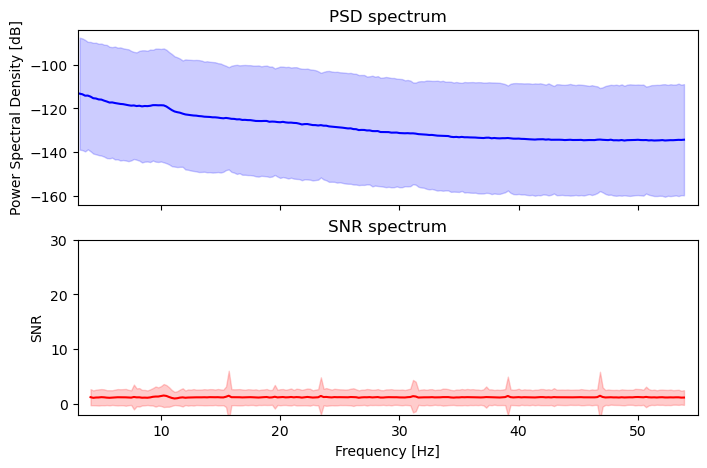

In [15]:
fig, axes = plt.subplots(2, 1, sharex="all", sharey="none", figsize=(8, 5))
freq_range = range(
    np.argmin(abs(freqs - 1.0)),
    np.argmin(abs(freqs - (fmax - 1)))
)

psds_plot = 10 * np.log10(psds)
psds_mean = psds_plot.mean(axis=(0, 1))[freq_range]
psds_std = psds_plot.std(axis=(0, 1))[freq_range]
axes[0].plot(freqs[freq_range], psds_mean, color="b")
axes[0].fill_between(
    freqs[freq_range], psds_mean - psds_std, psds_mean + psds_std, color="b", alpha=0.2
)
axes[0].set(title="PSD spectrum", ylabel="Power Spectral Density [dB]")

# SNR spectrum
snr_mean = snrs.mean(axis=(0, 1))[freq_range]
snr_std = snrs.std(axis=(0, 1))[freq_range]

axes[1].plot(freqs[freq_range], snr_mean, color="r")
axes[1].fill_between(
    freqs[freq_range], snr_mean - snr_std, snr_mean + snr_std, color="r", alpha=0.2
)
axes[1].set(
    title="SNR spectrum",
    xlabel="Frequency [Hz]",
    ylabel="SNR",
    ylim=[-2, 30],
    xlim=[fmin, fmax],
)
fig.show()

In [16]:
# define stimulation frequency
stim_freq = 25

In [17]:
# find index of frequency bin closest to stimulation frequency
i_bin_25hz = np.argmin(abs(freqs - stim_freq))
# could be updated to support multiple frequencies

# for later, we will already find the 50 Hz bin (1st harmonic)
i_bin_50hz = np.argmin(abs(freqs - 50))

In [18]:
# i_trial_12hz = np.where(epochs.annotations.description == "12hz")[0]
# i_trial_15hz = np.where(epochs.annotations.description == "15hz")[0]

In [19]:
# Define ROI electrodes for SuS (HBN dataset)
roi_sus = [f"E{i}" for i in range(69, 77)] + [f"E{i}" for i in range(81, 84)] + ["E88", "E89"]

# Find corresponding indices
picks_roi_sus = mne.pick_channels(epochs.info["ch_names"], roi_sus)

print("ROI channels:", [epochs.ch_names[i] for i in picks_roi_sus])

ROI channels: ['E69', 'E70', 'E71', 'E72', 'E73', 'E74', 'E75', 'E76', 'E81', 'E82', 'E83', 'E88', 'E89']


In [20]:
# Extract SNR at 25 Hz for all SuS trials, within ROI
snrs_target = snrs[:, picks_roi_sus, i_bin_25hz]

print("SuS task, all trials, SNR at 25 Hz")
print(f"Average SNR (SuS ROI): {snrs_target.mean():.2f}")

SuS task, all trials, SNR at 25 Hz
Average SNR (SuS ROI): 1.28


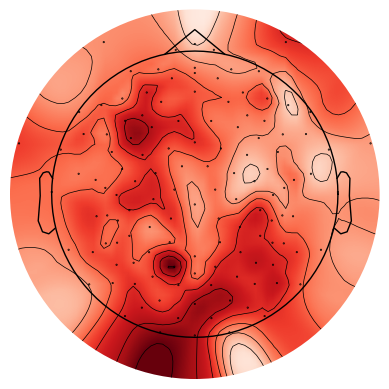

SuS task, all trials, SNR at 25 Hz
average SNR (all channels): 1.21
average SNR (SuS ROI): 1.28
25 Hz SNR in SuS ROI vs all channels: t = 1.980, p = 4.817e-02


In [21]:
# get average SNR at 25 Hz for ALL channels
snrs_25hz = snrs[:, :, i_bin_25hz]
snrs_25hz_chaverage = snrs_25hz.mean(axis=0)

# plot SNR topography at 25 Hz
fig, ax = plt.subplots(1)
mne.viz.plot_topomap(snrs_25hz_chaverage, epochs.info, vlim=(1, None), axes=ax)

print("SuS task, all trials, SNR at 25 Hz")
print(f"average SNR (all channels): {snrs_25hz_chaverage.mean():.2f}")
print(f"average SNR (SuS ROI): {snrs_target.mean():.2f}")

from scipy.stats import ttest_rel
tstat_roi_vs_scalp = ttest_rel(snrs_target.mean(axis=1), snrs_25hz.mean(axis=1))
print(
    f"25 Hz SNR in SuS ROI vs all channels: t = {tstat_roi_vs_scalp[0]:.3f}, "
    f"p = {tstat_roi_vs_scalp[1]:.3e}"
)


/tmp/ipykernel_2607119/1171890178.py:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


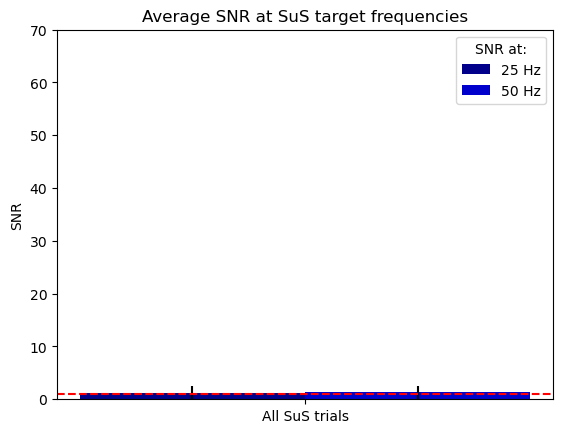

In [22]:
# Average SNR across ROI channels
snrs_roi = snrs[:, picks_roi_sus, :].mean(axis=1)

freq_plot = [25, 50]   # SuS fundamental + harmonic
color_plot = ["darkblue", "mediumblue"]
xpos_plot = [-0.25, 0.25]
fig, ax = plt.subplots()

labels = ["All SuS trials"]
x = np.arange(len(labels))  # one condition only
width = 0.6
res = dict()

# loop to plot SNRs at target frequencies
for i, f in enumerate(freq_plot):
    snrs_tmp = snrs_roi[:, np.argmin(abs(freqs - f))]
    SNR_tmp = [snrs_tmp.mean()]
    ax.bar(
        x + width * xpos_plot[i],
        SNR_tmp,
        width / len(freq_plot),
        yerr=snrs_tmp.std(),
        label=f"{f} Hz SNR",
        color=color_plot[i],
    )
    res[f"snrs_{f}hz"] = snrs_tmp

# Formatting
ax.set_ylabel("SNR")
ax.set_title("Average SNR at SuS target frequencies")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend([f"{f} Hz" for f in freq_plot], title="SNR at:")
ax.set_ylim([0, 70])
ax.axhline(1, ls="--", c="r")
fig.show()


In [23]:
# Compare 25 Hz and 50 Hz SNR across trials (averaged over ROI channels)
from scipy.stats import ttest_rel

snr_25hz = res["snrs_25hz"]
snr_50hz = res["snrs_50hz"]

tstat_25_vs_50 = ttest_rel(snr_25hz, snr_50hz)
print(
    f"SuS Trials: 25 Hz SNR vs 50 Hz SNR -> "
    f"t = {tstat_25_vs_50[0]:.3f}, p = {tstat_25_vs_50[1]:.3e}"
)


SuS Trials: 25 Hz SNR vs 50 Hz SNR -> t = -0.514, p = 6.071e-01


In [ ]:
stim_bandwidth = 0.5

# trial durations to test (2s up to 20s in steps of 2)
window_lengths = [i for i in range(2, 21, 2)]
window_snrs = [[]] * len(window_lengths)

for i_win, win in enumerate(window_lengths):
    # compute PSD on truncated data
    this_spectrum = epochs.compute_psd(
        "welch",
        n_fft=int(sfreq * win),
        n_overlap=0,
        n_per_seg=None,
        tmin=0,
        tmax=min(win, epochs.tmax),  # cap at available epoch length
        window="boxcar",
        fmin=fmin,
        fmax=fmax,
        verbose=False,
    )
    windowed_psd, windowed_freqs = this_spectrum.get_data(return_freqs=True)

    # bandwidth and neighbors for SNR computation
    bin_width = windowed_freqs[1] - windowed_freqs[0]
    skip_neighbor_freqs = (
        round((stim_bandwidth / 2) / bin_width - bin_width / 2.0 - 0.5)
        if (bin_width < stim_bandwidth)
        else 0
    )
    n_neighbor_freqs = int(
        (
            sum((windowed_freqs <= (stim_freq + stim_bandwidth)) & (windowed_freqs >= (stim_freq - stim_bandwidth)))
            - 1
            - 2 * skip_neighbor_freqs
        ) / 2
    )

    # compute SNR
    windowed_snrs = snr_spectrum(
        windowed_psd,
        noise_n_neighbor_freqs=n_neighbor_freqs if (n_neighbor_freqs > 0) else 1,
        noise_skip_neighbor_freqs=skip_neighbor_freqs,
    )
    window_snrs[i_win] = windowed_snrs[:, picks_roi_sus, np.argmin(abs(windowed_freqs - stim_freq))].mean(axis=1)

# Plot boxplot of SNR vs trial duration
fig, ax = plt.subplots(1)
ax.boxplot(window_snrs, tick_labels=window_lengths, orientation="vertical")
ax.set(
    title="Effect of trial duration on 25 Hz SNR (SuS task)",
    ylabel="Average SNR",
    xlabel="Trial duration [s]",
)
ax.axhline(1, ls="--", c="r")
fig.show()


ValueError: If n_per_seg is None n_fft is not allowed to be > n_times. If you want zero-padding, you have to set n_per_seg to relevant length. Got n_fft of 2000 while signal length is 1201.

: 

/tmp/ipykernel_335828/939895662.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


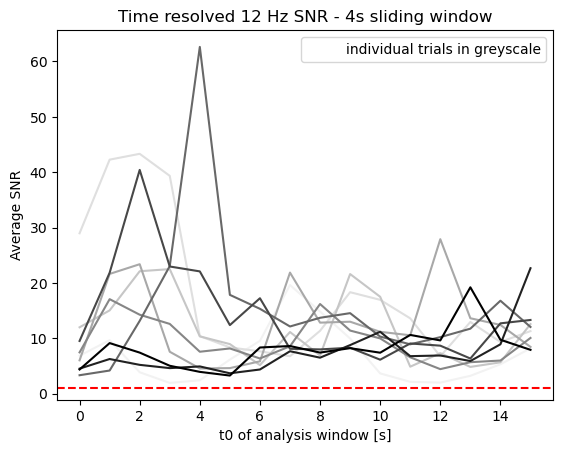

In [ ]:
# Sliding window analysis for SuS (25 Hz SSVEP)
window_length = 4
window_starts = [i for i in range(int(epochs.tmax) - window_length)]
window_snrs = [[]] * len(window_starts)

for i_win, win in enumerate(window_starts):
    # compute PSD on each window
    this_spectrum = epochs.compute_psd(
        "welch",
        n_fft=int(sfreq * window_length) - 1,
        n_overlap=0,
        n_per_seg=None,
        window="boxcar",
        tmin=win,
        tmax=win + window_length,
        fmin=fmin,
        fmax=fmax,
        verbose=False,
    )
    windowed_psd, windowed_freqs = this_spectrum.get_data(return_freqs=True)

    # define bandwidth of 1 Hz around stimfreq
    bin_width = windowed_freqs[1] - windowed_freqs[0]
    skip_neighbor_freqs = (
        round((stim_bandwidth / 2) / bin_width - bin_width / 2.0 - 0.5)
        if (bin_width < stim_bandwidth)
        else 0
    )
    n_neighbor_freqs = int(
        (
            sum((windowed_freqs <= (stim_freq + stim_bandwidth)) &
                (windowed_freqs >= (stim_freq - stim_bandwidth)))
            - 1
            - 2 * skip_neighbor_freqs
        ) / 2
    )

    # compute SNR at 25 Hz
    windowed_snrs = snr_spectrum(
        windowed_psd,
        noise_n_neighbor_freqs=n_neighbor_freqs if (n_neighbor_freqs > 0) else 1,
        noise_skip_neighbor_freqs=skip_neighbor_freqs,
    )
    window_snrs[i_win] = windowed_snrs[:, picks_roi_sus, np.argmin(abs(windowed_freqs - stim_freq))].mean(axis=1)

# Plot sliding-window SNR
fig, ax = plt.subplots(1)
colors = plt.colormaps["Greys"](np.linspace(0, 1, min(len(window_snrs[0]), 10)))
for i in range(len(colors)):
    ax.plot(window_starts, np.array(window_snrs)[:, i], color=colors[i])
ax.set(
    title=f"Time resolved 25 Hz SNR (SuS task) - {window_length}s sliding window",
    ylabel="Average SNR",
    xlabel="t0 of analysis window [s]",
)
ax.axhline(1, ls="--", c="r")
ax.legend(["individual trials in greyscale"])
fig.show()
